In [1]:
# Feature Analysis
!pip install pandas matplotlib


[notice] A new release of pip available: 22.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
# Automated Plots

import pandas as pd

def load_dataframe_from_file(file_name):
    df = pd.read_csv(file_name)
    return df

def prep_df(df):
    d = df.copy()
    d = d.sort_values("importance", ascending=False).reset_index(drop=True)
    d["cumulative"] = d["importance"].cumsum() / d["importance"].sum() * 100
    return d


In [3]:
from pathlib import Path

RESORUCE_PATH = Path("../evaluation").resolve()

In [4]:
SE_SUBJECTS = [
    "BRCTP",
    "java",
    "php",
    "python",
    "ruby",
]

KAGGLE_SUBJECTS = [
    "bank",
    "hotel_bookings",
    "job_change",
    "heart_failure",
    "water_potability",
    "spam"
]

In [5]:
data_frames = {}
for subject in SE_SUBJECTS + KAGGLE_SUBJECTS:
    print(subject)
    data_frame = load_dataframe_from_file(RESORUCE_PATH / f"{subject}_feature_imp.csv")
    data_frames[subject] = prep_df(data_frame)

BRCTP
java
php
python
ruby
bank
hotel_bookings
job_change
heart_failure
water_potability
spam


In [6]:
dfs = [
    ("Bug Report", data_frames["BRCTP"]),
    ("PHP Merge Conflict", data_frames["php"]),
    ("Java Merge Conflict", data_frames["java"]),
    ("Ruby Merge Conflict", data_frames["ruby"]),
    ("Heart Failure", data_frames["heart_failure"]),
    ("Bank Marketing", data_frames["bank"]),
    ("Hotel Bookings", data_frames["hotel_bookings"]),
    ("Job Changes", data_frames["job_change"]),
    ("Water Potability", data_frames["water_potability"]),
    ("Spam Mail", data_frames["spam"]),

]

In [7]:
colors = [
    "steelblue",     # blue
    "orange",        # orange
    "seagreen",      # green
    "purple",        # purple
    "firebrick",     # red
    "goldenrod",     # golden yellow
    "teal",          # teal
    "darkcyan",      # cyan/blue-green
    "slategray",     # gray
    "darkorchid",    # violet
]

In [8]:
import numpy as np

def choose_tick_positions(n, max_ticks=10):
    """
    Return rank positions (1..n) for x-ticks:
    - Always includes 1 and n
    - Caps total ticks at max_ticks
    - Computes a step that spaces ticks roughly evenly
    """
    if n <= max_ticks:
        return np.arange(1, n + 1)

    # ensure endpoints are kept while distributing the rest
    step = int(np.ceil((n - 1) / (max_ticks - 1)))  # e.g., n=100, max=10 => step=11
    ticks = np.arange(1, n + 1, step)
    if ticks[-1] != n:
        ticks = np.append(ticks, n)
    return ticks

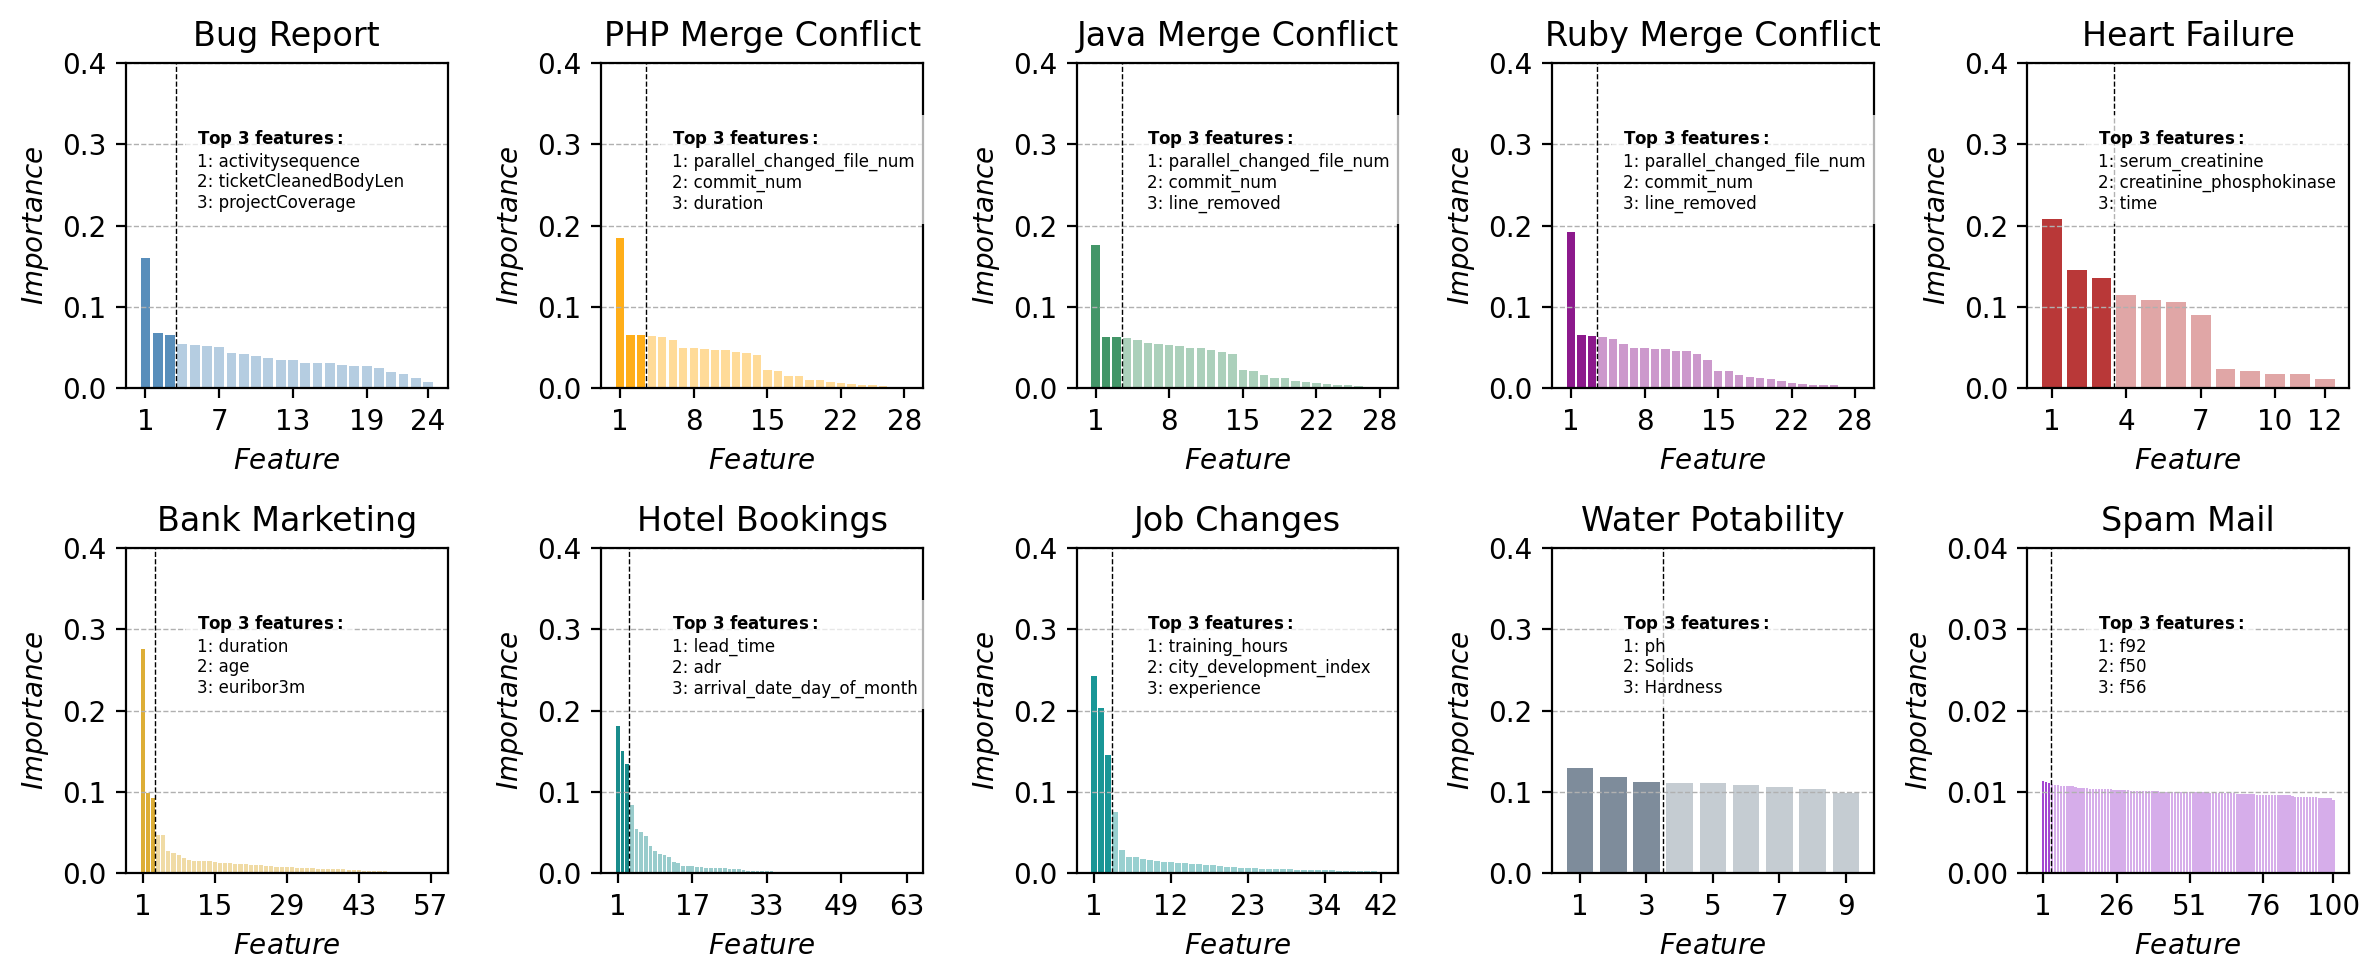

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def plot_importance_with_cum(ax, df, title, color):
    d = prep_df(df)
    x = np.arange(1, len(d) + 1)
    
    # Draw bars: top 3 with full opacity, rest with lighter opacity
    for i in range(len(d)):
        alpha = 0.9 if i < 3 else 0.4
        #label = d["feature"][i] if i < 3 else None  # only top 3 get labels
        ax.bar(x[i], d["importance"][i], color=color, alpha=alpha)
        
    # LaTeX axis labels
    ax.set_xlabel(r"$Feature$")
    ax.set_ylabel(r"$Importance$")
    ax.set_title(title)
    ax.grid(True, linestyle="--", linewidth=0.5, axis="y")

    if title == "Spam Mail":
        ax.set_ylim(0, 0.040)   # <<< fixed y-axis scale
    else:
        ax.set_ylim(0, 0.40)   # <<< fixed y-axis scale

    # Twin axis for cumulative %
    #ax2 = ax.twinx()
    #ax2.plot(x, d["cumulative"], marker="o")
    #ax2.axhline(80, linestyle="--")
    #ax2.axhline(90, linestyle="--")
    #ax2.set_ylabel("Cumulative (%)")
    #ax2.set_ylim(0, 100)
    
    ticks = choose_tick_positions(len(d), max_ticks=5)
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticks)

    # Vertical cutoff line between rank 3 and 4
    ax.axvline(3.5, color="black", linestyle="--", linewidth=0.5)

    # Legend text for top 3 features
    top3 = d["feature"].iloc[:3].tolist()
    top3_text = f"Top 3 features:\n1 = {top3[0]}\n2 = {top3[1]}\n3 = {top3[2]}"

    # Collect legends
    lines, labels = ax.get_legend_handles_labels()
    #lines2, labels2 = ax2.get_legend_handles_labels()

    # Add custom text entry for top 3
    # ax.legend(lines , labels + [top3_text], loc="upper right")
        # ---- Add TOP-3 as a text box (no patches/handles) ----
    top3 = d["feature"].iloc[:3].tolist()
    top3_text = (
        r"$\bf{Top\ 3\ features:}$"  # bold title
        + f"\n1: {top3[0]}"
        + f"\n2: {top3[1]}"
        + f"\n3: {top3[2]}"
    )
    ax.text(
        0.22, 0.8, top3_text,
        transform=ax.transAxes, ha="left", va="top",
        fontsize=6, bbox=dict(facecolor="white", alpha=0.7, edgecolor="none")
    )

# Create 2x2 subplot figure
fig, axes = plt.subplots(2, 5, figsize=(12, 5), dpi=200)
axes = axes.ravel()

for ax, (title, df), color in zip(axes, dfs, colors):
    plot_importance_with_cum(ax, df, title, color)

# If fewer than 4 frames, hide extra axes
for j in range(len(dfs), 4):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("feature-importance-plots-all.pdf", format="pdf", bbox_inches="tight")
plt.show()
